<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5217: Natural Language Processing</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 3.2: Recurrent Neural Networks</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Feedforward Neural Networks Language Models (NNLM)**

So far we have used neural networks for classification tasks like sentiment analysis. Now we turn to a different problem, **language modelling**: given theprevious words in a sentence, how likely is the next word?

Traditional count-based N-gram models struggle with this because they can only generalise to word sequences they have seen before. NNLMs solve this by learning **continuous word representations**, dense vectors that capture meaning, which allow the model to generalise to unseen word combinations far more effectively.

<br>

#### **The Architecture of Neural Networks Language Models (NNLM)**

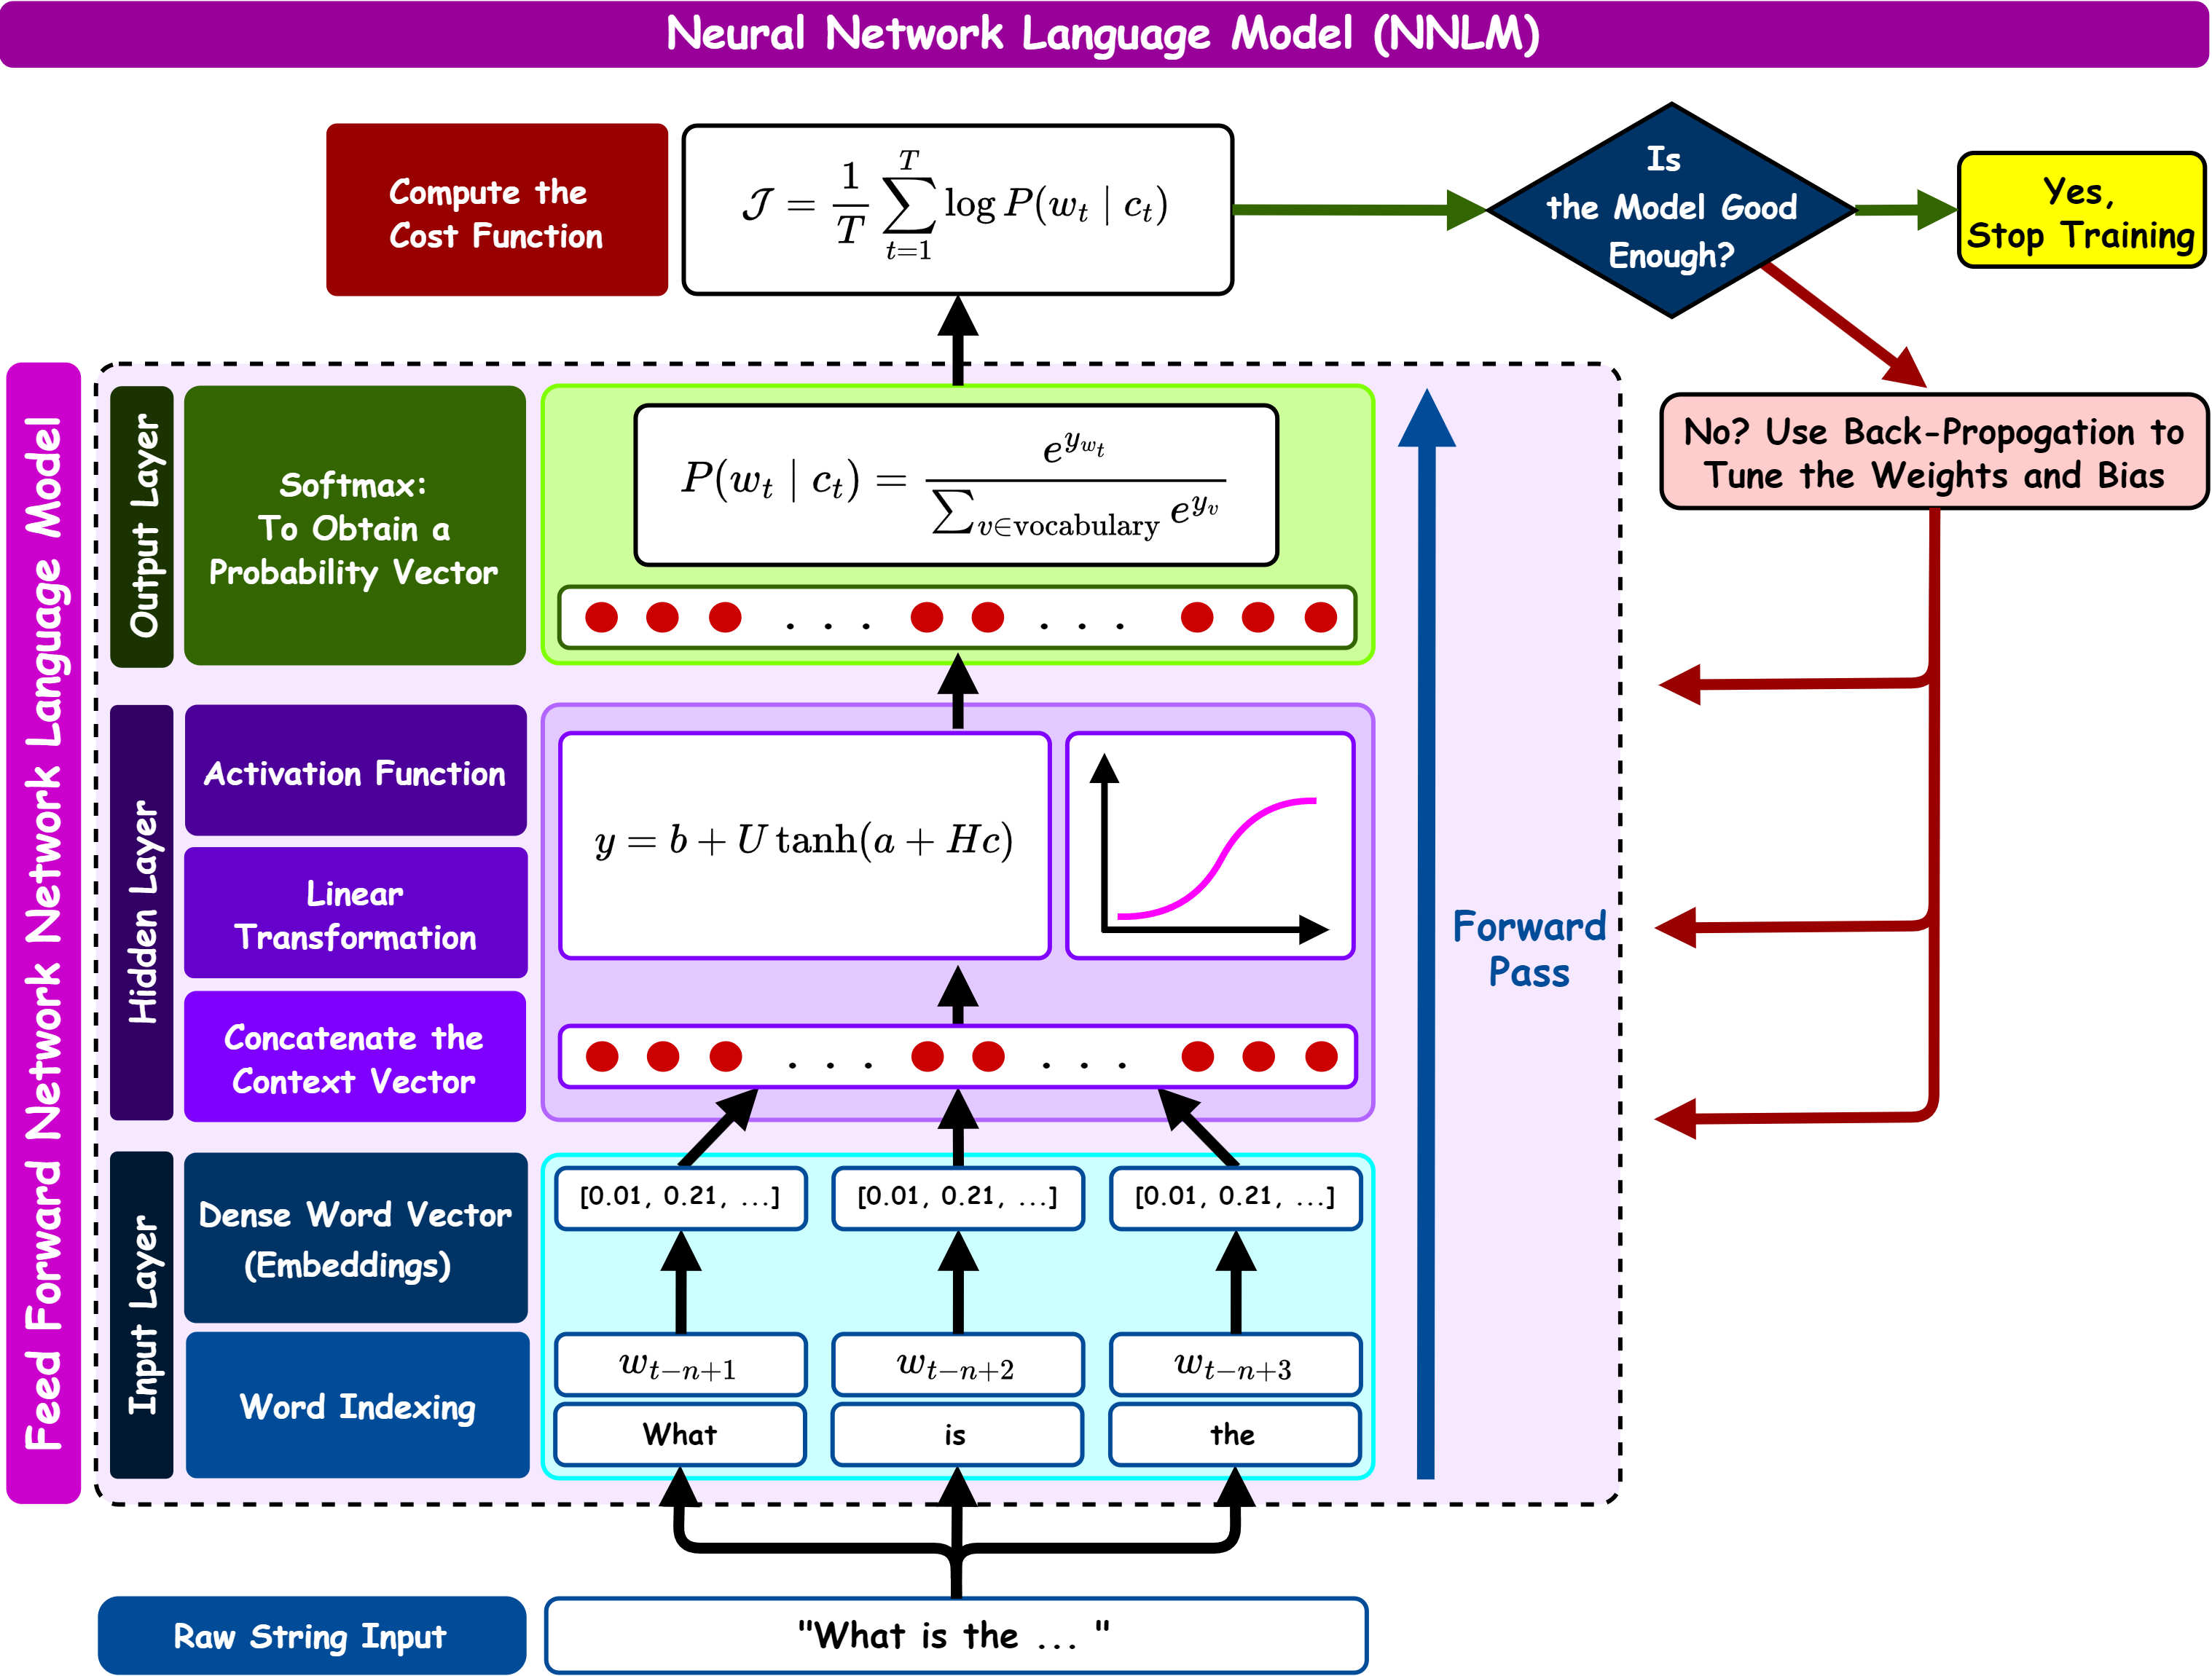

The goal of an NNLM is to predict the next word $w_t$ given the previous $n-1$, context words. Working from the bottom of the network upward:

**Step 1 Input: Context Word Indexes**

The previous $n-1$ words are represented as indexes into the vocabulary:

$$w_{t-n+1}, \quad w_{t-2}, \quad w_{t-1}$$

**Step 2 Lookup: Dense Word Vectors**

Each index is mapped to a **dense vector** (also called a word embedding), a compact, continuous representation of that word learned during training. This is fundamentally different from one-hot vectors, which are sparse and treat every word as completely unrelated to every other word.

**Step 3 Concatenate, Transform and Activation Function (Forward Pass Equation)**

All context word vectors are concatenated into a single vector and passed through one or more hidden layers with non-linear activations, allowing the network to learn complex interactions between the context words. The entire forward pass of the NNLM can be expressed in a single equation. This combines the linear transformation and activation function of the hiddenlayer, and the linear transformation of the output layer all in one line:

$$y = b + U\tanh(a + Hc)$$

**Step 4 Softmax Output**

The final hidden layer output is passed through a **softmax** function to produce a probability distribution over the entire vocabulary:

$$P(w_t = i \mid \text{context})$$

The $i$-th output value is the probability that the next word is the $i$-th word in the vocabulary. The output vector has one entry per word in the vocabulary, and all entries sum to 1.

<br>

#### **The Forward Pass Equation**

The entire forward pass of the NNLM can be expressed in a single equation. This combines the linear transformation and activation function of the hiddenlayer, and the linear transformation of the output layer all in one line:

$$y = b + U\tanh(a + Hc)$$

Where:
- $c$ = the concatenated context word embeddings (the input)
- $H$ = weight matrix connecting the input to the hidden layer
- $a$ = bias term for the hidden layer
- $a + Hc$ = linear transformation of the input
- $\tanh(a + Hc)$ = activation function applied to the linear transformation, producing the hidden layer $h$
- $U$ = weight matrix connecting the hidden layer to the output
- $b$ = bias term for the output layer
- $y$ = the final raw output scores, one per word in the vocabulary

Breaking it down step by step:

| Step | Expression | What it does |
|---|---|---|
| 1 | $c$ | Concatenated word embeddings fed in as input |
| 2 | $a + Hc$ | Linear transformation — weighted sum plus bias |
| 3 | $\tanh(a + Hc)$ | Activation function — adds non-linearity, produces hidden layer $h$ |
| 4 | $b + U\tanh(a + Hc)$ | Second linear transformation — projects hidden layer to output scores |
| 5 | $y$ | Raw scores fed into softmax to produce probabilities |

Note that $\tanh$ is used here instead of sigmoid as the hidden layer activation function. Tanh outputs values between $-1$ and $+1$ (compared to sigmoid's $0$ to $1$), which works better in practice because it is zero-centred, meaning the gradients flow more evenly during backpropagation, making training faster and more stable.

#### **The Softmax Function**

Softmax is a mathematical trick that converts any vector of raw scores into a valid probability distribution — all values become positive and sum to 1. For each word $v$ in the vocabulary, the probability of the next word being $w_t$ given the context $c_t$ is:

$$P(w_t \mid c_t) = \frac{e^{y_{w_t}}}{\sum_{v \in \text{vocabulary}} e^{y_v}}$$

More explicitly, given context words $w_{t-n+1} \ldots w_{t-1}$:

$$P(w_t \mid w_{t-n+1} \ldots w_{t-1}) = \frac{e^{y_{w_t}}}{\sum_{v \in \text{vocabulary}} e^{y_v}}$$

The intuition is simple, **exponentiate** each score to make it positive, then **divide by the sum** of all exponentiated scores to normalise into probabilities. A higher raw score for a word means a higher probability of being the next word.

<br>

#### **Training the NNLM**

Training follows the same forward-backward pattern as before. The objective is to maximise the average log probability of the correct next word across all positions $t$ in the training corpus of length $T$:

$$\mathcal{J} = \frac{1}{T} \sum_{t=1}^{T} \log P(w_t \mid c_t)$$

1. **Forward pass** feed the context words through the network and compute
$P(w_t \mid c_t)$ using softmax
2. **Backward pass** backpropagate the error and update all parameters
including the word embedding vectors themselves

<br>

#### **Dense Word Representations**

A useful byproduct of training an NNLM is that the word embedding matrix learnedd uring training captures meaningful relationships between words. Words that appear in similar contexts end up with similar vectors, so the model implicitly learns that "cat" and "dog" are more related to each other than either is to "democracy", purely from seeing them used in similar ways in the training data.

| Feature | Count-based N-grams | NNLM |
|---|---|---|
| Word representation | Sparse, discrete indexes | Dense, continuous vectors |
| Generalisation | Only seen sequences | Can generalise to unseen combinations |
| Context captured | Fixed window of counts | Learned interactions via hidden layers |
| Bonus output | None | Reusable word embeddings |
